# Proyecto 1 - Inteligencia Artificial
## Predicción de Tarifas de Transporte en NYC
Alina Carías, Ignacio Méndez, Ariela Mishaan y Diego Soto

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


## Limpieza

### Carga y descripción de datos

In [66]:
# Carga de datos
df = pd.read_csv("train_final.csv")
df.head()

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21 UTC,-73.844311,40.721319,-73.841610,40.712278,1
1,2010-01-05 16:52:16.0000002,16.9,2010-01-05 16:52:16 UTC,-74.016048,40.711303,-73.979268,40.782004,1
2,2011-08-18 00:35:00.00000049,5.7,2011-08-18 00:35:00 UTC,-73.982738,40.761270,-73.991242,40.750562,2
3,2012-04-21 04:30:42.0000001,7.7,2012-04-21 04:30:42 UTC,-73.987130,40.733143,-73.991567,40.758092,1
4,2010-03-09 07:51:00.000000135,5.3,2010-03-09 07:51:00 UTC,-73.968095,40.768008,-73.956655,40.783762,1


**Variable objetivo:** fare_amount. 

In [67]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 8 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   key                1000000 non-null  object 
 1   fare_amount        1000000 non-null  float64
 2   pickup_datetime    1000000 non-null  object 
 3   pickup_longitude   1000000 non-null  float64
 4   pickup_latitude    1000000 non-null  float64
 5   dropoff_longitude  999990 non-null   float64
 6   dropoff_latitude   999990 non-null   float64
 7   passenger_count    1000000 non-null  int64  
dtypes: float64(5), int64(1), object(2)
memory usage: 61.0+ MB


,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,1000000.000000,1000000.000000,1000000.000000,999990.000000,999990.000000,1000000.000000
mean,11.348079,-72.526640,39.929008,-72.527860,39.919954,1.684924
std,9.822090,12.057937,7.626154,11.324494,8.201418,1.323911
min,-44.900000,-3377.680935,-3116.285383,-3383.296608,-3114.338567,0.000000
25%,6.000000,-73.992060,40.734965,-73.991385,40.734046,1.000000
50%,8.500000,-73.981792,40.752695,-73.980135,40.753166,1.000000
75%,12.500000,-73.967094,40.767154,-73.963654,40.768129,2.000000
max,500.000000,2522.271325,2621.628430,45.581619,1651.553433,208.000000


### Valores Nulos

In [68]:
df.isnull().sum()

key                   0
fare_amount           0
pickup_datetime       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude    10
dropoff_latitude     10
passenger_count       0
dtype: int64

In [69]:
df = df.dropna()

### Limpieza de Etiquetas y otras columnas

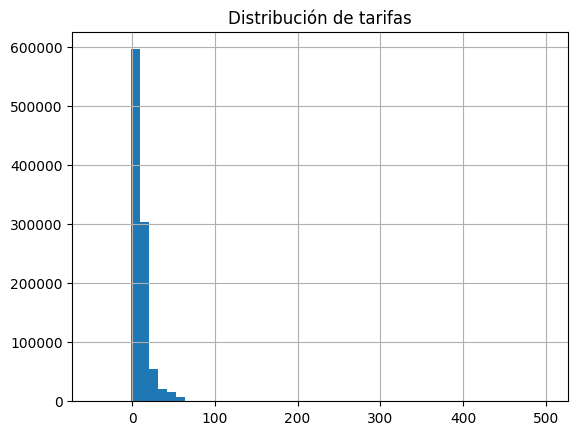

In [70]:
df["fare_amount"].hist(bins=50)
plt.title("Distribución de tarifas")
plt.show()

Se puede ver que las tarifas se encuentran entre 0 y $80, en general. Se eliminan entonces los datos que tienen tarifas mayores a $80. 

In [71]:
# dejar solo las etiquetas de la variable objetivo mayores a 0
df = df[df["fare_amount"] > 0]

# quitar valores muy altos para las tarifas
df = df[df["fare_amount"] < 80]

In [72]:
# limpieza de pasajeros
df["passenger_count"].value_counts()

# quitar los valores que no son reales: 0
df = df[(df["passenger_count"] > 0) & (df["passenger_count"] <= 6)]

### Limpieza Geográfica

Se conservan solo los datos que estén en NYC: 
- Latitud: 40 a 42
- Longitud: -75 a -72

**Fuente:** https://www.latlong.net/place/new-york-city-ny-usa-1848.html

In [73]:
df = df[
    (df["pickup_latitude"].between(40, 42)) &
    (df["dropoff_latitude"].between(40, 42)) &
    (df["pickup_longitude"].between(-75, -72)) &
    (df["dropoff_longitude"].between(-75, -72))
]

### Revisión de datos limpios

In [74]:
df.describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,974755.000000,974755.000000,974755.000000,974755.000000,974755.000000,974755.000000
mean,11.248981,-73.975170,40.751063,-73.974215,40.751390,1.691176
std,9.182506,0.038832,0.029945,0.037519,0.032960,1.306309
min,0.010000,-74.968142,40.052722,-74.964263,40.041180,1.000000
25%,6.000000,-73.992272,40.736577,-73.991557,40.735618,1.000000
50%,8.500000,-73.982085,40.753407,-73.980583,40.753880,1.000000
75%,12.500000,-73.968324,40.767572,-73.965322,40.768415,2.000000
max,79.990000,-72.702870,41.800252,-72.694838,41.923820,6.000000


## Análisis Exploratorio

### Distribución de Tarifas

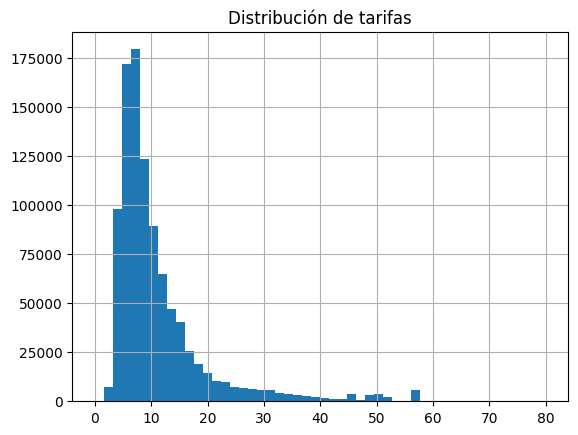

In [75]:
df["fare_amount"].hist(bins=50)
plt.title("Distribución de tarifas")
plt.show()

In [76]:
len((df[df["fare_amount"] > 60]))

1572

Se puede observar que la mayoría de los datos se concentran entre 0 y 20. Esto indica que las tarifas son bastante bajas. Hay 1572 outliers que se encuentran arriba de $60. 

### Distribución de Pasajeros

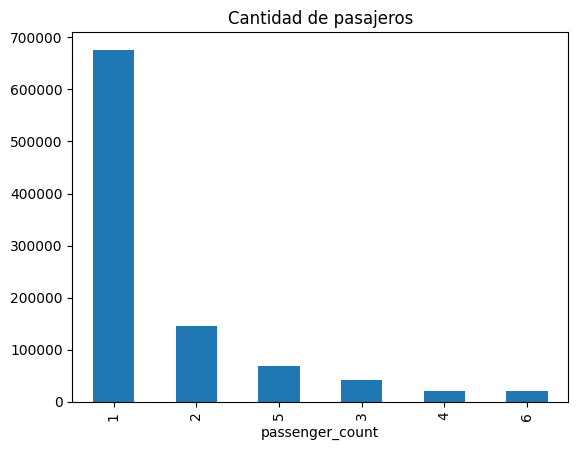

In [77]:
df["passenger_count"].value_counts().plot(kind="bar")
plt.title("Cantidad de pasajeros")
plt.show()

### Ubicaciones

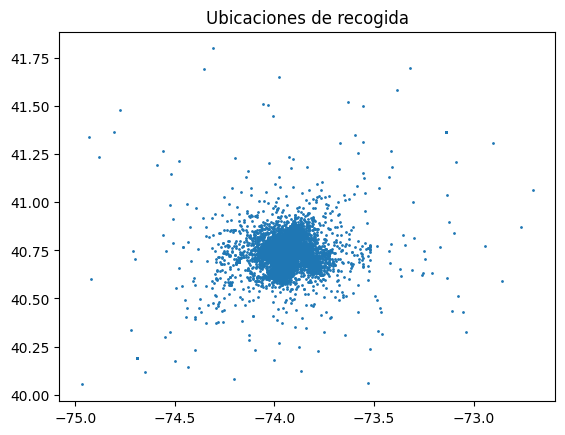

In [78]:
plt.scatter(df["pickup_longitude"], df["pickup_latitude"], s=1)
plt.title("Ubicaciones de recogida")
plt.show()

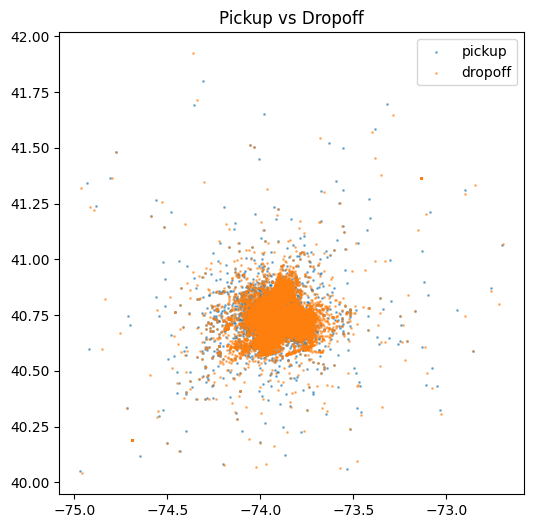

In [79]:
# distribución pickups vs dropoffs
plt.figure(figsize=(6,6))
plt.scatter(df["pickup_longitude"], df["pickup_latitude"], s=1, label="pickup", alpha=0.5)
plt.scatter(df["dropoff_longitude"], df["dropoff_latitude"], s=1, label="dropoff", alpha=0.5)
plt.legend()
plt.title("Pickup vs Dropoff")
plt.show()

### Relación tarifa vs pasajeros

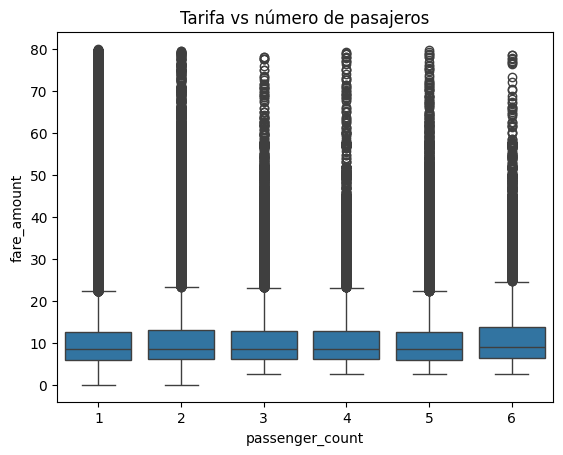

In [80]:
sns.boxplot(x="passenger_count", y="fare_amount", data=df)
plt.title("Tarifa vs número de pasajeros")
plt.show()

El gráfico de caja y bigotes muestra que la tarifa no cambia según los pasajeros. Esto indica que la variable ```passenger_count``` no es influyente para nuestra variable objetivo. 

## Feature Engineering (Análisis de Características)

### Distancia 

In [81]:
# fórmula de Haversine
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # radio de la Tierra en km

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

In [82]:
df["distance_km"] = haversine(
    df["pickup_latitude"],
    df["pickup_longitude"],
    df["dropoff_latitude"],
    df["dropoff_longitude"]
)

In [85]:
# limpieza de distancias
df = df[df["distance_km"] > 0]
df = df[df["distance_km"] < 100]

### Variables temporales

In [87]:
df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"])

In [88]:
# crear las variables
df["hour"] = df["pickup_datetime"].dt.hour
df["day_of_week"] = df["pickup_datetime"].dt.dayofweek
df["month"] = df["pickup_datetime"].dt.month
df["year"] = df["pickup_datetime"].dt.year

In [89]:
df["is_weekend"] = df["day_of_week"].isin([5,6]).astype(int)

In [90]:
df["is_rush_hour"] = df["hour"].isin([7,8,9,16,17,18,19]).astype(int)

### Zonas de interés

In [91]:
JFK = (-73.7781, 40.6413)
LGA = (-73.8740, 40.7769)
EWR = (-74.1745, 40.6895)

In [113]:
def is_near_airport(lat, lon, airport_lat, airport_lon, threshold=10):
    return haversine(lat, lon, airport_lat, airport_lon) < threshold

In [114]:
df["pickup_jfk"] = is_near_airport(df["pickup_latitude"], df["pickup_longitude"], *JFK)
df["dropoff_jfk"] = is_near_airport(df["dropoff_latitude"], df["dropoff_longitude"], *JFK)

df["pickup_lga"] = is_near_airport(df["pickup_latitude"], df["pickup_longitude"], *LGA)
df["dropoff_lga"] = is_near_airport(df["dropoff_latitude"], df["dropoff_longitude"], *LGA)

df["pickup_ewr"] = is_near_airport(df["pickup_latitude"], df["pickup_longitude"], *EWR)
df["dropoff_ewr"] = is_near_airport(df["dropoff_latitude"], df["dropoff_longitude"], *EWR)

In [115]:
cols = ["pickup_jfk","dropoff_jfk","pickup_lga","dropoff_lga","pickup_ewr","dropoff_ewr"]
df[cols] = df[cols].astype(int)

In [118]:
df["pickup_ewr"].describe()

count    964285.0
mean          0.0
std           0.0
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           0.0
Name: pickup_ewr, dtype: float64

### Análisis de las características

In [109]:
df.columns

Index(['key', 'fare_amount', 'pickup_datetime', 'pickup_longitude',
       'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
       'passenger_count', 'distance_km', 'hour', 'day_of_week', 'month',
       'year', 'is_weekend', 'is_rush_hour', 'pickup_jfk', 'dropoff_jfk',
       'pickup_lga', 'dropoff_lga', 'pickup_ewr', 'dropoff_ewr'],
      dtype='object')

#### Tarifa por hora

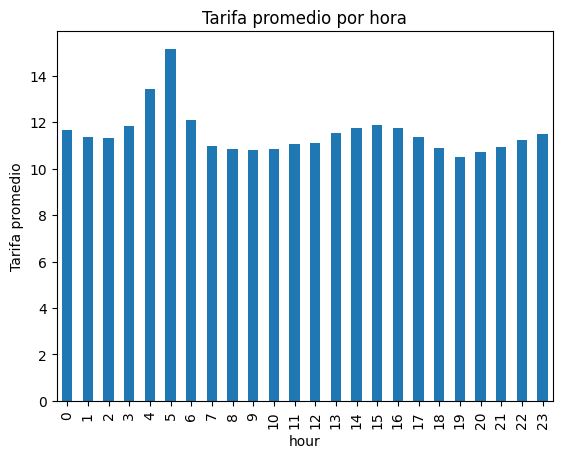

In [ ]:
# tarifa promedio por hora
df.groupby("hour")["fare_amount"].mean().plot(kind="bar")
plt.title("Tarifa promedio por hora")
plt.ylabel("Tarifa promedio")
plt.show()

Se puede ver que durante las horas del día existen variaciones. Por ejemplo, de 3 a 6 de la mañana, las tarifas suben bastante. En las horas pico de la tarde, entre 2pm y 5pm, las tarifas también suben, pero el cambio no es tanto. 

#### Tarifa por día de la semana

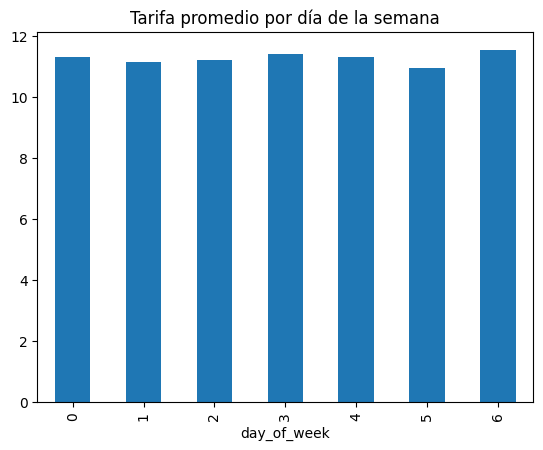

In [99]:
# día de la semana
df.groupby("day_of_week")["fare_amount"].mean().plot(kind="bar")
plt.title("Tarifa promedio por día de la semana")
plt.show()

El día de la semana no pareciera ser una variable significativa para la variable objtivo. Se puede ver que el valor de la tarifa no cambia tanto según el día de la semana (0 = lunes, 6 = domingo). 

#### Tarifa por mes

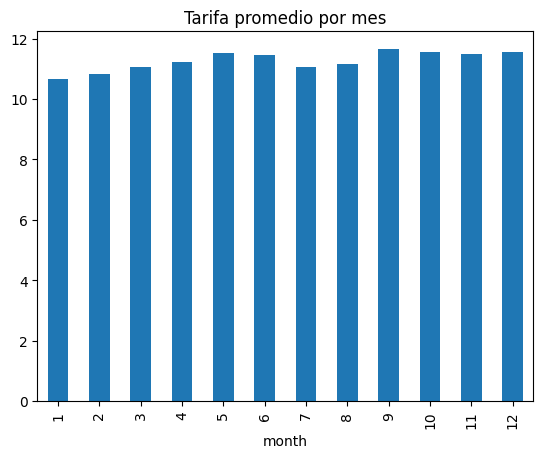

In [100]:
# mes 
df.groupby("month")["fare_amount"].mean().plot(kind="bar")
plt.title("Tarifa promedio por mes")
plt.show()

Las tarifas del taxi no parecieran tener estacionalidad. Aunque hay unos meses con tarifas un poco más altas y otras con unas un poco más bajas, el cambio en general es muy bajo.  

#### Tarifa por año

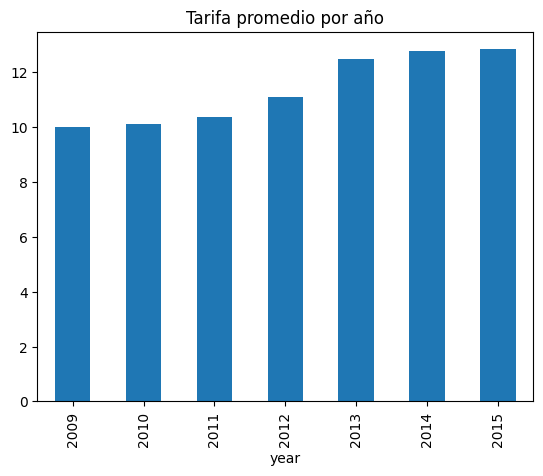

In [101]:
# año
df.groupby("year")["fare_amount"].mean().plot(kind="bar")
plt.title("Tarifa promedio por año")
plt.show()

El gráfico de barras muestra que las tarifas promedio han ido subiendo con los años. En 2009, el promedio se encontraba alrededor de $10, y fue subiendo gradualmente, hasta llegar al 2015 con una tarifa promedio de alrededor de $13. 

#### Fin de semana

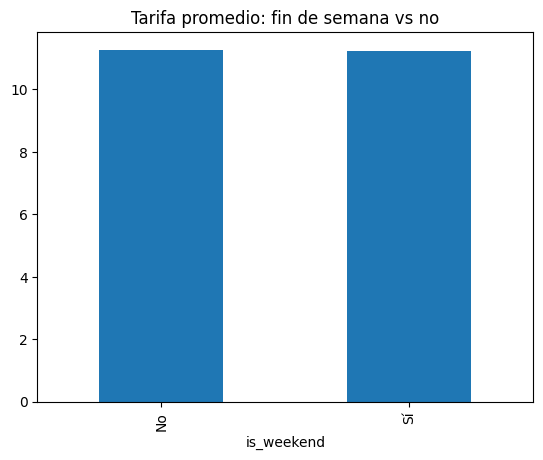

In [110]:
df.groupby("is_weekend")["fare_amount"].mean().plot(kind="bar")
plt.title("Tarifa promedio: fin de semana vs no")
plt.xticks([0,1], ["No", "Sí"])
plt.show()

El hecho de ser fin de semana no influye significativamente en la tarifa promedio de los taxis, eso quiere decir que la variable no es tan influyente. 

#### Hora pico

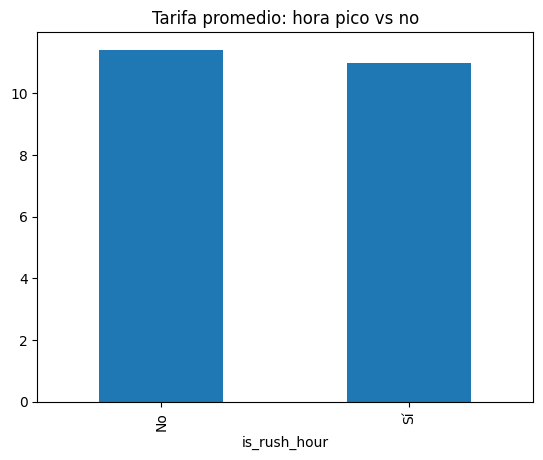

In [103]:
df.groupby("is_rush_hour")["fare_amount"].mean().plot(kind="bar")
plt.title("Tarifa promedio: hora pico vs no")
plt.xticks([0,1], ["No", "Sí"])
plt.show()

La hora pico tampoco parece ser un factor de influencia en la tarifa. Los datos que no son en hora pico mostraron tener una tarifa más alta. Esto indica que en realidad el dato de la hora pico no determina la tarifa. 

#### Distancia

/var/folders/p9/c7lshh9n1j55x6_b26v_sx1h0000gn/T/ipykernel_61416/558831060.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("distance_bin")["fare_amount"].mean().plot(kind="bar")


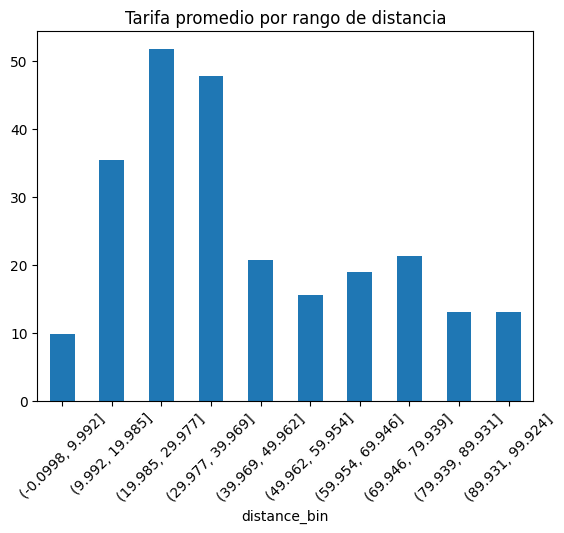

In [119]:
df["distance_bin"] = pd.cut(df["distance_km"], bins=10)

df.groupby("distance_bin")["fare_amount"].mean().plot(kind="bar")
plt.title("Tarifa promedio por rango de distancia")
plt.xticks(rotation=45)
plt.show()

#### Matriz de correlación

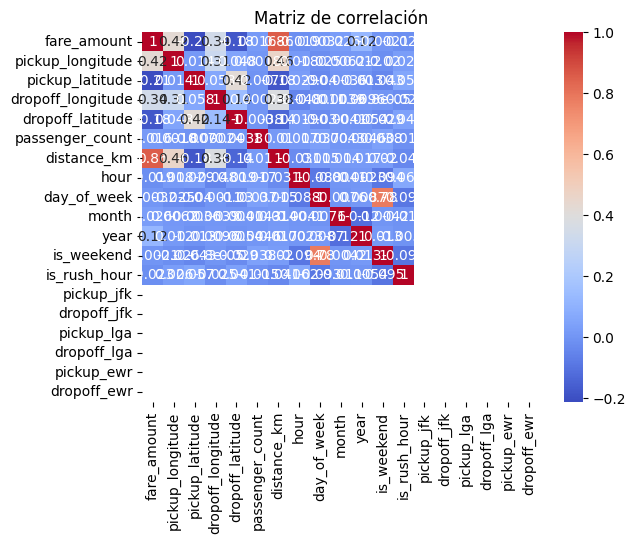

In [120]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()